# House Price Prediction using Linear Regression

## Objective
Predict House prices using machine learning based on various house features

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
df = pd.read_csv("D:\Power BI\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
print("Rows and Columns: ",df.shape)

Rows and Columns:  (545, 13)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


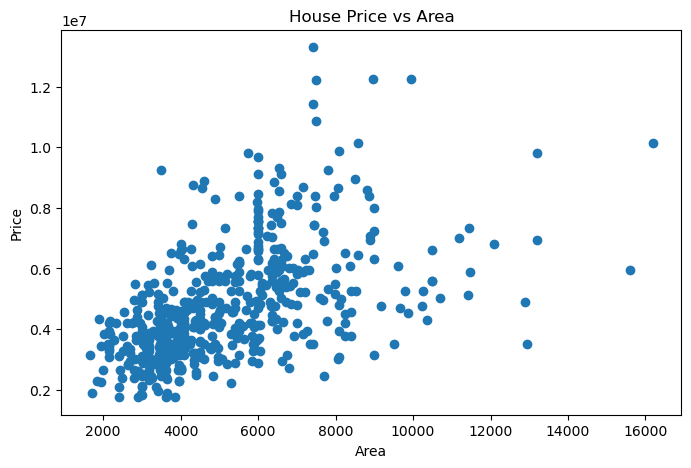

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['area'],df['price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("House Price vs Area")
plt.show()


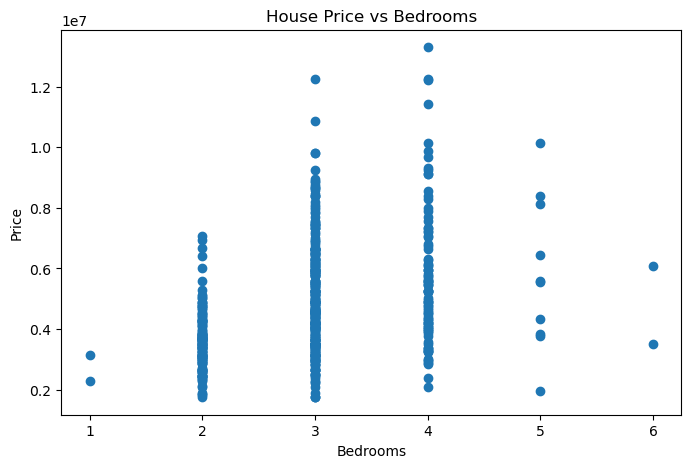

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df['bedrooms'],df['price'])
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("House Price vs Bedrooms")
plt.show()

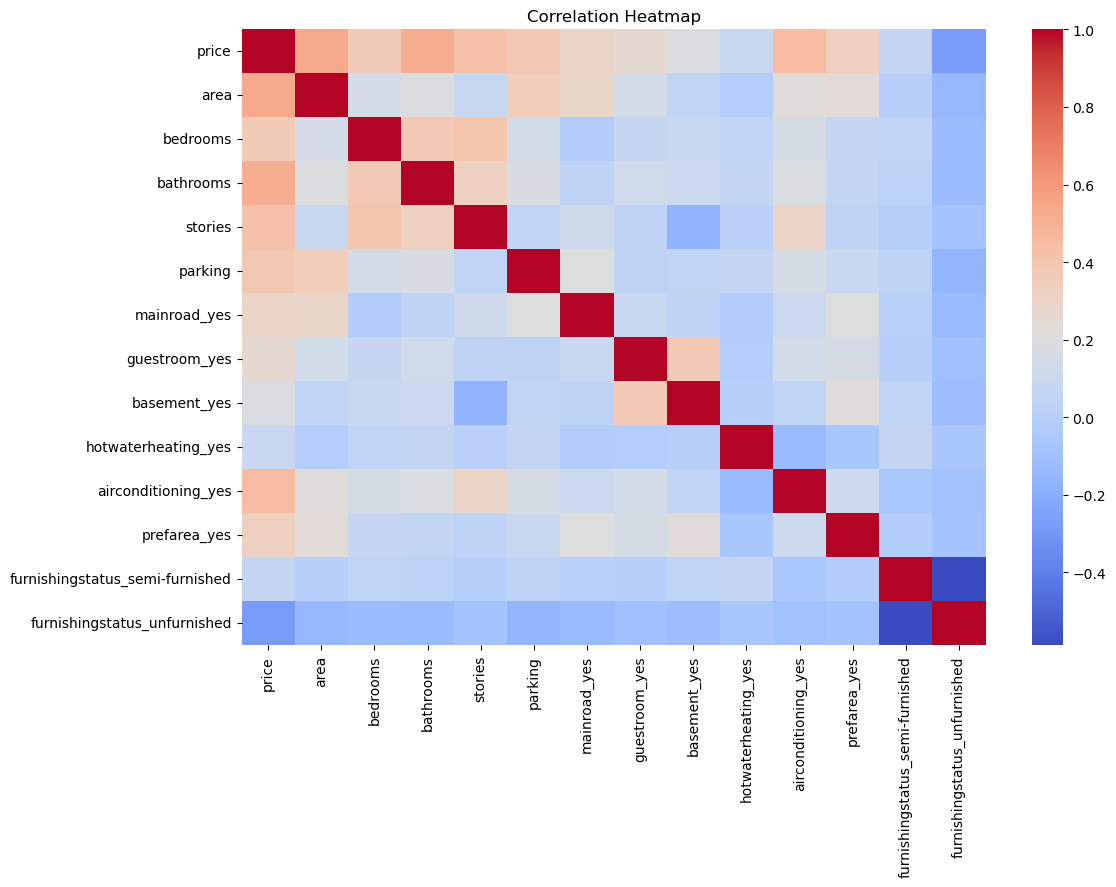

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [11]:
x=df.drop('price',axis=1)
y=df['price']

In [12]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

In [13]:
model = LinearRegression()

model.fit(x_train,y_train)

print("Model Trained succesfully")

Model Trained succesfully


In [14]:
y_pred = model.predict(x_test)

y_pred[:5]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.32722559, 3294646.25725955])

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

MAE : 970043.4039201635
MSE : 1754318687330.663
R2 Score : 0.6529242642153186


In [16]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


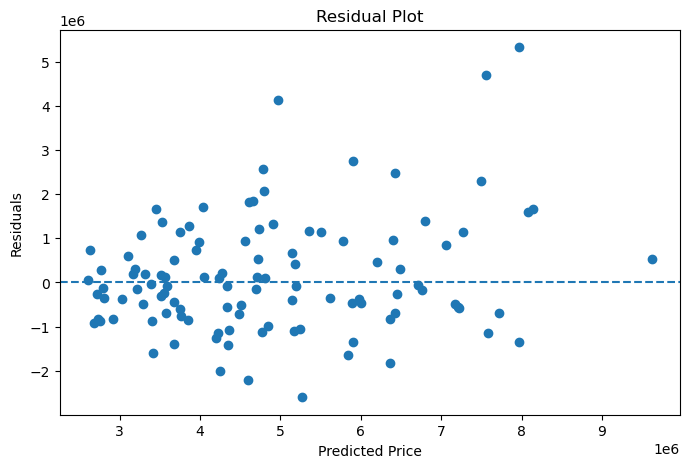

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [18]:
joblib.dump(model, "house_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


## Conclusion

A Linear Regression model was developed to predict house prices.

The model was trained and evaluated using MAE, MSE, and R² Score.

The trained model was saved as house_price_model.pkl for future predictions.


In [19]:
def predict_house_price(features):
    """
    Predict house price using trained Linear Regression model.

    Parameters:
    features (list): List of house features in the same order as X columns.

    Returns:
    float: Predicted house price
    """

    prediction = model.predict([features])

    return prediction[0]

In [21]:
sample_house = x.iloc[0].values

predicted_price = predict_house_price(sample_house)

print("Predicted House Price:", predicted_price)

Predicted House Price: 7968276.126387383


D:\github\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
